In [1]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
#import bioframe
import pickle
#import cooler 
import os

#import bbi 

from matplotlib.gridspec import GridSpec

from scipy.sparse import coo_matrix
from multiprocessing import Pool
import pickle
import timeit
import sys
sys.setrecursionlimit(4000)

from itertools import product
from scipy.ndimage import gaussian_filter
from scipy.sparse import coo_matrix
from scipy.ndimage import gaussian_filter1d
from scipy.stats import expon

import pyximport
pyximport.install(setup_args={"include_dirs": np.get_include()})

from DSB_smcTranslocator_v2 import smcTranslocatorDirectional 

# from contact_map_generator_from_shortest_path import contact_map_generator_from_SMC_list



#from cooltools.lib.numutils import logbins

from functools import reduce

#from cooltools.lib.numutils import coarsen, logbins
import matplotlib.patches as patches
import copy

import itertools
#from contact_map_generator_v2 import ChainLayout
#import contact_map_generator_v2 as cl

def initModel(idx):
    #unchanging parameters
    BELT_ON=0
    BELT_OFF=1
    switchRate = 0 
    SWITCH_PROB= switchRate # switching rate
    PUSH=0
    PAIRED=0
    SLIDE=1
    SLIDE_PAUSEPROB=0.99 
    loop_prefactor=1.5 
    FULL_LOOP_ENTROPY=1 
    FRACTION_ONESIDED=0
    
    longlived_smcNum = 0
    # Extruder dynamics frequency of sampling parameters 
    numExtruderSteps = 500 # steps taken for each simulation sample
    numInitializationSteps = 10000 # how long we take to equilibrate the simulation

    #longlived_fraction = 0
    PAUSEPROB= 0 # motor pause probability
        
    SWITCH =  np.ones(L,dtype=np.double)*SWITCH_PROB
    
    # convolve with Gaussian - but need to make the integral still add up to the bias factor
    #birthArray[(L//2-len_bias):(L//2+len_bias)] = gaussian_filter1d(birthArray[(L//2-len_bias):(L//2+len_bias)], 2, mode='constant')
    #print(birthArray[(L//2-len_bias):(L//2+len_bias)])
    # gaussian_filter1d( B, 2.09, mode='constant' ),
    
    pauseArray = PAUSEPROB*np.ones(L, dtype=np.double) 

    slidePauseArray = np.zeros(L, dtype=np.double) + SLIDE_PAUSEPROB
    oneSidedArray = np.zeros(smcNum, dtype=np.int64)
    longlived_oneSidedArray = np.zeros(longlived_smcNum, dtype=np.int64)
    belt_on_array = np.zeros(smcNum, dtype=np.double) + BELT_ON
    belt_off_array = np.zeros(smcNum, dtype=np.double) + BELT_OFF
    spf=slidePauseArray*(1.-(1.-SLIDE_PAUSEPROB)*np.exp(-1.*loop_prefactor))
    spb=slidePauseArray*(1.-(1.-SLIDE_PAUSEPROB)*np.exp(loop_prefactor))
    
    ################### TAD BOUNDARY CONDITION###################
    # stallLeft is from the LEF perspective, boundaryStrength is from the CTCF perspective
    
    ##################################################################

    # load birthArray, DeathArray, stallLeftArray, stallRightArray

    transloc = smcTranslocatorDirectional(birthArray, deathArray, deathArray, stallLeftArray, stallRightArray, pauseArray,
                                         smcNum, longlived_smcNum, oneSidedArray,longlived_oneSidedArray, FRACTION_ONESIDED, slide=SLIDE,
                                         slidepauseForward=spf, slidepauseBackward=spb, switch=SWITCH, pushing=PUSH,
                                        belt_on=belt_on_array, belt_off=belt_off_array,SLIDE_PAUSEPROB=SLIDE_PAUSEPROB) 
    return transloc


In [2]:
def initModel(smc_params, stallLeftArray, stallRightArray, boundary_coords, loading_loc_biases, L, PAUSEPROB):
    # unchanging
    BELT_ON = 0
    BELT_OFF = 1
    switchRate = 0
    SWITCH_PROB = switchRate
    PUSH = 0
    PAIRED = 0
    SLIDE = 1
    SLIDE_PAUSEPROB = 0.99
    loop_prefactor = 1.5
    FULL_LOOP_ENTROPY = 1
    FRACTION_ONESIDED = 0

    # sweep
    processivity = smc_params['processivity']
    separations = smc_params['separations']
    longlived_fraction = smc_params.get('longlived_fraction', 0)
    longlived_boost = smc_params.get('longlived_boost_factor', 1)
    lifetime_extension = smc_params.get('ctcf_boost_factor', 1)

    # birth array (loading targeted)
    if loading_loc_biases is not None:
        birthArray = loading_loc_biases.copy()
        birthArray = birthArray / sum(birthArray)  # Normalize
    else:
        birthArray = np.ones(L)/L

    # Base rate (times 0.5 to account for two-sided extrusion)
    base_death_rate = 1. / (0.5 * processivity / (1 - PAUSEPROB))
    deathArray = np.zeros(L, dtype=np.double) + base_death_rate

    if len(boundary_coords) > 0:
        deathArray[boundary_coords] = base_death_rate / lifetime_extension

    if longlived_fraction == 0:
        smcNum = int(L // separations)
        longlived_smcNum = 0
        longlived_deathArray = np.zeros(L, dtype=np.double) + base_death_rate
    else:
        normal_sep = separations / (1 - longlived_fraction)
        smcNum = int(L // normal_sep)

        longlived_sep = separations / longlived_fraction
        longlived_smcNum = int(L // longlived_sep)

        longlived_base_rate = base_death_rate / longlived_boost
        longlived_deathArray = np.zeros(L, dtype=np.double) + longlived_base_rate

        if len(boundary_coords) > 0:
            longlived_deathArray[boundary_coords] = longlived_base_rate / lifetime_extension

    SWITCH = np.ones(L, dtype=np.double) * SWITCH_PROB
    pauseArray = PAUSEPROB * np.ones(L, dtype=np.double)
    slidePauseArray = np.zeros(L, dtype=np.double) + SLIDE_PAUSEPROB
    oneSidedArray = np.zeros(smcNum, dtype=np.int64)
    longlived_oneSidedArray = np.zeros(longlived_smcNum, dtype=np.int64)
    belt_on_array = np.zeros(smcNum, dtype=np.double) + BELT_ON
    belt_off_array = np.zeros(smcNum, dtype=np.double) + BELT_OFF

    # Calculate directional sliding pause probabilities
    spf = slidePauseArray * (1. - (1. - SLIDE_PAUSEPROB) * np.exp(-1. * loop_prefactor))
    spb = slidePauseArray * (1. - (1. - SLIDE_PAUSEPROB) * np.exp(loop_prefactor))

    transloc = smcTranslocatorDirectional(
        birthArray,
        deathArray,
        longlived_deathArray,
        stallLeftArray,  # The fully tiled arrays
        stallRightArray,  # The fully tiled arrays
        pauseArray,
        smcNum,
        longlived_smcNum,
        oneSidedArray,
        longlived_oneSidedArray,
        FRACTION_ONESIDED,
        slide=SLIDE,
        slidepauseForward=spf,
        slidepauseBackward=spb,
        switch=SWITCH,
        pushing=PUSH,
        belt_on=belt_on_array,
        belt_off=belt_off_array,
        SLIDE_PAUSEPROB=SLIDE_PAUSEPROB
    )

    return transloc

In [3]:
def build_tiled_boundaries(ctcf_configs, L):
    
    config = ctcf_configs[0] # the multiple configs are from when i thought i'd change up the regions across the chrom

    boundaryStrengthsL = np.zeros(L, dtype=np.double)
    boundaryStrengthsR = np.zeros(L, dtype=np.double)
    boundary_coordinates = []
    
    abs_sites_L = config['sites_L']
    abs_sites_R = config['sites_R']

    boundaryStrengthsL[abs_sites_L] = config['probs_L']
    boundaryStrengthsR[abs_sites_R] = config['probs_R']

    boundary_coordinates.extend(abs_sites_L)
    boundary_coordinates.extend(abs_sites_R)

    return boundaryStrengthsL, boundaryStrengthsR, np.array(boundary_coordinates, dtype=int)

def build_tiled_mm_permm(mm_configs, L, cohesins_per_mm, loading_width):
    config = mm_configs[0]
    mmLoc = np.ones(L, dtype=np.double)

    loading_bias = cohesins_per_mm / loading_width
    abs_sites = config['sites']

    for site in abs_sites:
        mmLoc[(site-loading_width//2):(site+loading_width//2)] = loading_bias
        print(site-loading_width//2, site+loading_width//2)

    return mmLoc, loading_bias # this fulfills the need for birthArray, but is not normalized

def generate_param_grid(param_dict):
    keys, values = zip(*param_dict.items())
    for bundle in product(*values):
        yield dict(zip(keys, bundle))


In [4]:
## parameter defs

ctcf_configs = [{
    'name': 'default',
    'sites_L': np.array([574, 694, 866, 1241, 1390, 1580, 1752, 1800]),
    'probs_L': np.array([0.6, 0.8 , 0.95, 0.1 , 0.6, 0.6, 0.8, 0.1 ]),
    'sites_R': np.array([200, 330, 724, 1425, 1433, 1604]),
    'probs_R': np.array([0.9, 0.3 , 0.95, 0.4 , 0.3, 0.4 ])
}]


simulation_sweep_space = {
    'processivity': [300],
    'separations': [240],
    'ctcf_boost_factor': [4],
    'longlived_fraction': [0],
    'longlived_boost_factor': [20],
    'dsb_boost_factor': [0],
    'llp': [2],
    'h': [0.4],
    'loading_width': [8], # width of targeted loading in kb,
    'cohesins_per_mm':[None, 128] # if none, that means no bias
}

mm_configs = [{
    'name': 'default',
    'sites': np.array([456, 1054, 1507]),
}]

L = 2000
pause_prob = 1 - 0.0025

In [5]:
save_base_folder = "/mnt/md1/varshini/Blood/cohesin_traj_sim"
num_cores = 10
nsamples = 100
nsamples_dots = 60 
samps_per_core = 100000
initialization_steps = 10000
steps_per_sample = 1000

In [10]:
from typing import Any, Iterator

def flatten2(element: Any) -> Iterator[Any]:
    """Flatten a nested set of iterables into a single stream of elements"""
    
    try:
        sequence = iter(element)
        for item in sequence:
            yield from flatten2(item)
        
    except TypeError:
        yield element


Starting Run: sim_proc300_sep240_ctcf4_n128_h0.4_llp2_w8
Config: {'processivity': 300, 'separations': 240, 'ctcf_boost_factor': 4, 'longlived_fraction': 0, 'longlived_boost_factor': 20, 'dsb_boost_factor': 0, 'llp': 2, 'h': 0.4, 'loading_width': 8, 'cohesins_per_mm': 128}
452 460
1050 1058
1503 1511


NameError: name 'flatten2' is not defined

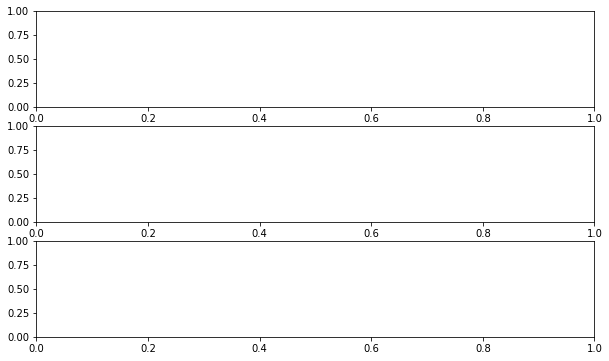

Process ForkPoolWorker-10:
Process ForkPoolWorker-9:
Process ForkPoolWorker-2:
Process ForkPoolWorker-3:
Process ForkPoolWorker-6:
Process ForkPoolWorker-1:
Process ForkPoolWorker-7:
Process ForkPoolWorker-8:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/varshini/anaconda3/envs/openmm-dev/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/home/varshini/anaconda3/envs/openmm-dev/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/home/varshini/anaconda3/envs/openmm-dev/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/varshini/anaconda3/envs/openmm-dev/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
  

In [7]:
stallLeftArray, stallRightArray, boundary_coords = build_tiled_boundaries(ctcf_configs, L)
lef_hists = []
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

for idx, config in enumerate(generate_param_grid(simulation_sweep_space)):
        if idx == 0:
            continue
        run_name = (f"sim_proc{config['processivity']}_sep{config['separations']}"
                    f"_ctcf{config['ctcf_boost_factor']}_n{config['cohesins_per_mm']}"
                    f"_h{config['h']}_llp{config['llp']}_w{config['loading_width']}")
        save_folder = os.path.join(save_base_folder, run_name)

        if not os.path.exists(save_folder):
            os.makedirs(save_folder)

        print(f"\n{'=' * 50}")
        print(f"Starting Run: {run_name}")
        print(f"Config: {config}")
        print(f"{'=' * 50}")

        if config['cohesins_per_mm'] is not None:
            loading_loc_biases, loading_bias = build_tiled_mm_permm(mm_configs, L,
                                                      config['cohesins_per_mm'], config['loading_width'])
        else:
            loading_loc_biases = None
            loading_bias = 1
        
        smc_params = {
            'processivity': config['processivity'],
            'separations': config['separations'],
            'ctcf_boost_factor': config['ctcf_boost_factor'],
            'longlived_fraction': config['longlived_fraction'],
            'longlived_boost_factor': config['longlived_boost_factor'],
            'dsb_boost_factor': config['dsb_boost_factor'],
            'loading_loc_biases': loading_loc_biases
        }
        
        #birthArray, deathArray, stallLeftArray, stallRightArray, smcNum         
        SMCTran_list = [initModel(smc_params, stallRightArray, 
                                  stallLeftArray, boundary_coords, 
                                  loading_loc_biases, L, pause_prob) for _ in range(num_cores)]

        lp = 2
        H = 0.4 # these are sweepable remember

        def doOne(idx): 
            X = []
            Y = []
            P = []
            C = []

            SMCTran = SMCTran_list[idx]
            SMCTran.steps(initialization_steps)

            lef_list = []
            tot_bonds = []
            # loops 
            for s in range(samps_per_core):

                # get the SMC locations
                SMCTran.steps(steps_per_sample)
                x,y = SMCTran.getSMCs()

                # add the SMC pairs and plectoneme pairs to the bonds list (i.e. lef_pairs)
                lef_pairs = [(x[j],y[j]) for j in range(len(x))]
                lef_list.append(lef_pairs) # i think this is the SMCs object that we can access from the 3D h5s        

            pickle.dump(lef_list,open(os.path.join(save_folder,'loops_{}.pkl'.format(idx)),'wb'))
            return lef_list
#             # generate maps
#             for ic in range(len(lef_list)):
#                 smcs = np.array(lef_list[ic])
#                 cl = None
#                 try:
#                     if len(smcs)==0:
#                         smcs = [(0,1)]
#                     cl = ChainLayout(smcs,L)
#                 except:
#                     print("Pseudoknot formed count:{}".format(ic))
#                     print(cl)

#                     cl = None
#                 if cl is None:
#                     continue

#                 # subsample from distribution (for Pc(s))
#                 vals = sorted(np.random.choice(L,nsamples, replace=False))
#                 for ix in range(len(vals)):
#                     for iy in range(ix+1,len(vals)):
#                         x = vals[ix]
#                         y = vals[iy]
#                         deff = cl.get_dist(x,y,H=H,lp=lp)
#                         if deff == 0:
#                             pc = 1
#                         else:
#                             pc = 1/np.sqrt(deff)**3
#                         if not np.isnan(pc):
#                             X.append(x)
#                             Y.append(y) # x
#                             P.append(pc) # probability
#                             C.append(1) # counts


#             Z = coo_matrix((P,(X,Y)),shape=(L,L))
#             Zcount = coo_matrix((C,(X,Y)),shape=(L,L))

#             try:       
#                 with open(os.path.join(filename,'hmap_{}.pkl'.format(idx)),'wb') as FULLNAME:
#                     pickle.dump({'Z':Z,'Zcount':Zcount},FULLNAME)
#             except:
#                  print("Failed at {}".format(idx))

#             return Z, Zcount

        pool = Pool(num_cores)
        lef_list = pool.map(doOne, np.arange(num_cores))
        SMC_pos =  list(flatten2(lef_list))
        counts, _ = np.histogram(SMC_pos, bins=np.arange(0, 2000, 4))
        lef_hists.append([counts])
        axs[idx].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
        axs[idx].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
        axs[idx].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
        axs[idx].hist(SMC_pos, 500, fill=False, histtype='step', color='#CC3311');
                
        del SMCTran_list
        print('Done!')
h_diff = lef_hists[1][0] - lef_hists[0][0]
axs[2].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
axs[2].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].bar(x=np.arange(0, 2000, 4)[:-1], height=h_diff, width=4)
plt.ylim([-1000, 1000])

 #       tad_start, tad_end, pad = (0, 900_000, 50000 )
#         Z_list = [z[0].toarray() for z in ret_val]
#         Zcount_list = [z[1].toarray() for z in ret_val]
#         Z_list = [z+z.T for z in Z_list]
#         Zcount_list = [z+z.T for z in Zcount_list]
#         Z = reduce(lambda a,b : a+b,Z_list)
#         Zcount = reduce(lambda a,b : a+b,Zcount_list)
#         zz = coarsen(np.nanmean,Z/Zcount,{0:10,1:10},trim_excess=True)

#         plt.imshow(np.log10(zz),cmap='YlOrBr',
#                extent=tuple(np.array([tad_start-pad,tad_end+pad,tad_end+pad,tad_start-pad])/1e6),
#                   aspect='equal',vmax=np.percentile(np.log(zz),99.9))

#         plt.savefig(os.path.join(filename,'Heatmap.pdf'))
#         plt.title(f"config {idx}: loading bias {b}")

#         plt.show()
#         plt.clf()

        ## Next plot some goodness of fit statistics



   


In [40]:
flattened = list(flatten2(lef_list))



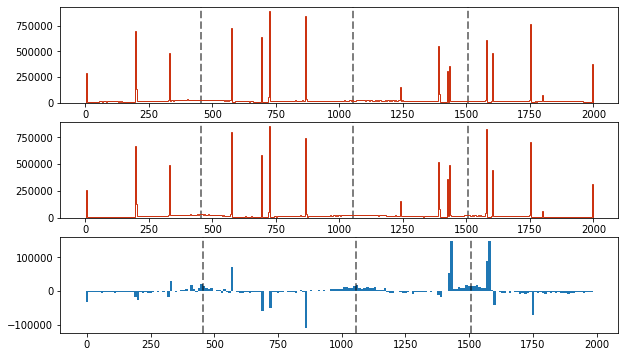

In [15]:
lef_hists = []
fig, axs = plt.subplots(3, 1, figsize=(10, 6))
bin_step = 10
for idx, config in enumerate(generate_param_grid(simulation_sweep_space)):
    run_name = (f"sim_proc{config['processivity']}_sep{config['separations']}"
                    f"_ctcf{config['ctcf_boost_factor']}_n{config['cohesins_per_mm']}"
                    f"_h{config['h']}_llp{config['llp']}_w{config['loading_width']}")
    save_folder = os.path.join(save_base_folder, run_name) 
    lef_list = []
    for i in range(10):
        
        with open(os.path.join(save_folder, f'loops_{i}.pkl'), 'rb') as f:
            lef_list_curr = pickle.load(f)

        lef_list.append(lef_list_curr)
    SMC_pos =  list(flatten2(lef_list))
    counts_binned, _ = np.histogram(SMC_pos, bins=np.arange(0, 2000, bin_step))
    lef_hists.append([counts_binned])
    
    axs[idx].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
    axs[idx].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
    axs[idx].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
    axs[idx].hist(SMC_pos, 500, fill=False, histtype='step', color='#CC3311');
                

h_diff = lef_hists[1][0] - lef_hists[0][0]
axs[2].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
axs[2].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].bar(x=np.arange(0, 2000, bin_step)[:-1], height=h_diff, width=bin_step)
plt.savefig("/mnt/md0/varshini/Analysis/Blood/figs_v4/cohesin_traj_demo.svg")

In [59]:
np.shape(lef_list)

(10, 10000, 8, 2)

In [52]:
SMC_pos

[1,
 45,
 1527,
 1551,
 1485,
 1504,
 1709,
 1752,
 429,
 487,
 1505,
 1526,
 1552,
 1580,
 141,
 209,
 1,
 47,
 1527,
 1551,
 1482,
 1504,
 1708,
 1752,
 428,
 490,
 1505,
 1526,
 1552,
 1580,
 137,
 211,
 1,
 50,
 1527,
 1551,
 1481,
 1504,
 1708,
 1752,
 426,
 493,
 1505,
 1526,
 1552,
 1580,
 134,
 214,
 1,
 53,
 1527,
 1551,
 1478,
 1504,
 1700,
 1752,
 423,
 495,
 1505,
 1526,
 1552,
 1580,
 128,
 218,
 1,
 57,
 1527,
 1551,
 1475,
 1505,
 1695,
 1752,
 420,
 499,
 1248,
 1255,
 1552,
 1580,
 126,
 220,
 1,
 62,
 1526,
 1551,
 1472,
 1508,
 1694,
 1752,
 419,
 500,
 1245,
 1258,
 1552,
 1580,
 123,
 222,
 1,
 64,
 1523,
 1551,
 1471,
 1512,
 1692,
 1752,
 418,
 505,
 1244,
 1261,
 1552,
 1580,
 119,
 227,
 1,
 66,
 1522,
 1551,
 1470,
 1513,
 1691,
 1752,
 413,
 510,
 1241,
 1262,
 1552,
 1580,
 117,
 228,
 1,
 70,
 1519,
 1551,
 621,
 622,
 1687,
 1752,
 409,
 515,
 1240,
 1267,
 1552,
 1580,
 115,
 231,
 1,
 70,
 1519,
 1551,
 619,
 625,
 1686,
 1752,
 406,
 516,
 1237,
 1270,


<BarContainer object of 999 artists>

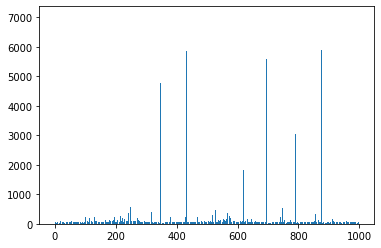

In [20]:
plt.bar(x=np.arange(0, 1000, 1)[:-1], height=lef_hists[0][0])

(-1000.0, 1000.0)

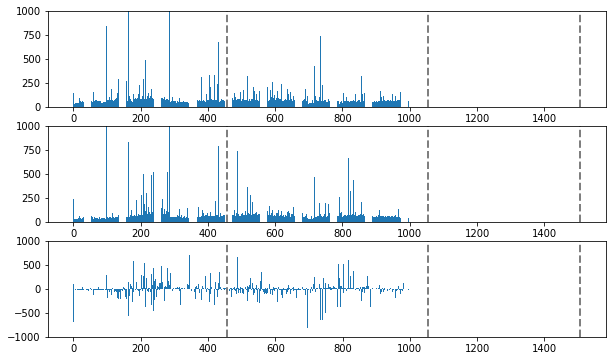

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

for idx in range(2):
        axs[idx].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
        axs[idx].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
        axs[idx].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
        axs[idx].bar(x=np.arange(0, 1000, 1)[:-1], height=lef_hists[idx][0]);
        axs[idx].set_ylim([0, 1000])
                
h_diff = lef_hists[1][0] - lef_hists[0][0]
axs[2].axvline(456, linewidth=2, color='k', alpha=0.5, linestyle='--', label='MM location')
axs[2].axvline(1054, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].axvline(1507, linewidth=2, color='k', alpha=0.5, linestyle='--')
axs[2].bar(x=np.arange(0, 1000, 1)[:-1], height=h_diff, width=2)
plt.ylim([-1000, 1000])

(0.0, 2000.0)

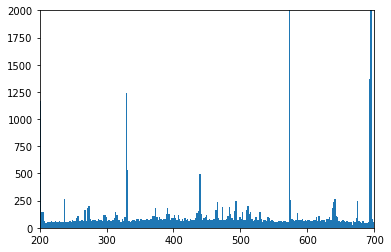

In [60]:
plt.hist(SMC_pos, bins=1000)
plt.xlim([200,700])
plt.ylim([0, 2000])

In [35]:
out = list(flattened)

In [36]:
out

[]